# Explore Percentile Bar Statistics for all Experiments

This creates bar plots the for spinup statistics.

Using levante python kernel "1 Python 3" (can be recreated from `../environment-standard.yml`)

In [1]:
import os, sys, glob
import xarray as xr
import numpy as np
import datetime

import pylab as plt
import seaborn as sns
sns.set_context('talk')

## Input

In [2]:
base_path = '/work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics'
filelist = sorted( glob.glob(f'{base_path}/joined*nc') )
nexp = len(filelist)

In [3]:
for i, fname in enumerate( filelist ):
    print(i, fname )

0 /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width100km_reinit12h.nc
1 /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width100km_reinit24h.nc
2 /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width200km_reinit12h.nc
3 /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width200km_reinit24h.nc
4 /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width300km_reinit24h_single.nc
5 /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width400km_reinit24h_single.nc


In [4]:
dset = {}
explist = []
for fname in filelist:
    print(f'...open {fname}')
    d = xr.open_dataset(fname)
    expname = fname.split('-')[-1].replace('.nc','')
    
    dset[expname] = d
    explist +=[expname,]

...open /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width100km_reinit12h.nc
...open /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width100km_reinit24h.nc
...open /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width200km_reinit12h.nc
...open /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width200km_reinit24h.nc
...open /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width300km_reinit24h_single.nc
...open /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width400km_reinit24h_single.nc


In [5]:
for expname in explist:
    
    dset[expname]['time'] = dset[expname].time  / 12.
    dset[expname]['time'].attrs = {'units':'hours'}

In [6]:
d_std = {}

for expname in explist:
    d = dset[expname]
    d_std[expname] = (d  - d.isel(time=0)).sel( quantile = slice(0.1,0.9)) # / d_offset.std('time')


## Plotting

In [7]:
varnames = ['pres_sfc', 't_2m', 'tqc_dia', 'tqi_dia']

scale = [1e-2,1, 1e3, 1e3,]

In [8]:
titles = ['Surface Pressure / hPa',
          '2m Temperature / K',
#          '(c) 2m Specific Humidity / (g kg${}^{-1}$)',
#          '(d) Total Column Water Vapor / mm',
          'Liquid Water Path / (g m${}^{-2}$)',
          'Ice Water Path / (g m${}^{-2}$)',]

ylabels = ['PDF / (hPa${}^{-1}$)',
           'PDF / (K${}^{-1}$)',
#           'PDF / (kg g${}^{-1}$)',
#           'PDF / (mm${}^{-1}$)',
           'PDF / (m${}^{2}$ g${}^{-1}$)',
           'PDF / (m${}^{2}$ g${}^{-1}$)',
          ]           

In [9]:
vlims = {}


for iexp, expname in enumerate( explist ):
    print(f'... use {expname}')
    dsq = d_std[expname].squeeze()
    d05 = dsq.sel(time = 0.5)
    dref = dsq.sel(time = [0,2]).mean('time')

    
    
    for i, vname in enumerate( varnames ): 
        v = scale[i]*(d05 - dref)[vname]

        vmin, vmax = np.percentile( v.data.flatten(), [5,95])

        if vname not in vlims:
            vlims[vname] = (vmin, vmax)
        else:
            vmin_before, vmax_before = vlims[vname]
            vlims[vname] = (np.minimum(vmin, vmin_before), np.maximum(vmax, vmax_before))


... use width100km_reinit12h
... use width100km_reinit24h
... use width200km_reinit12h
... use width200km_reinit24h
... use width300km_reinit24h_single
... use width400km_reinit24h_single


In [10]:
explist

['width100km_reinit12h',
 'width100km_reinit24h',
 'width200km_reinit12h',
 'width200km_reinit24h',
 'width300km_reinit24h_single',
 'width400km_reinit24h_single']

In [11]:
exp_describs = []
for expname in explist:
    desc = expname.replace('_single','')
    
    desc = desc.replace('_','\n').replace('init','init=')
    desc = desc.replace('width100km', 'narrow')
    desc = desc.replace('width200km', 'medium')
    desc = desc.replace('width300km', 'large')
    desc = desc.replace('width400km', 'x-large')
    
    exp_describs +=[desc,]

... use width100km_reinit12h
... use width100km_reinit24h
... use width200km_reinit12h
... use width200km_reinit24h
... use width300km_reinit24h_single
... use width400km_reinit24h_single


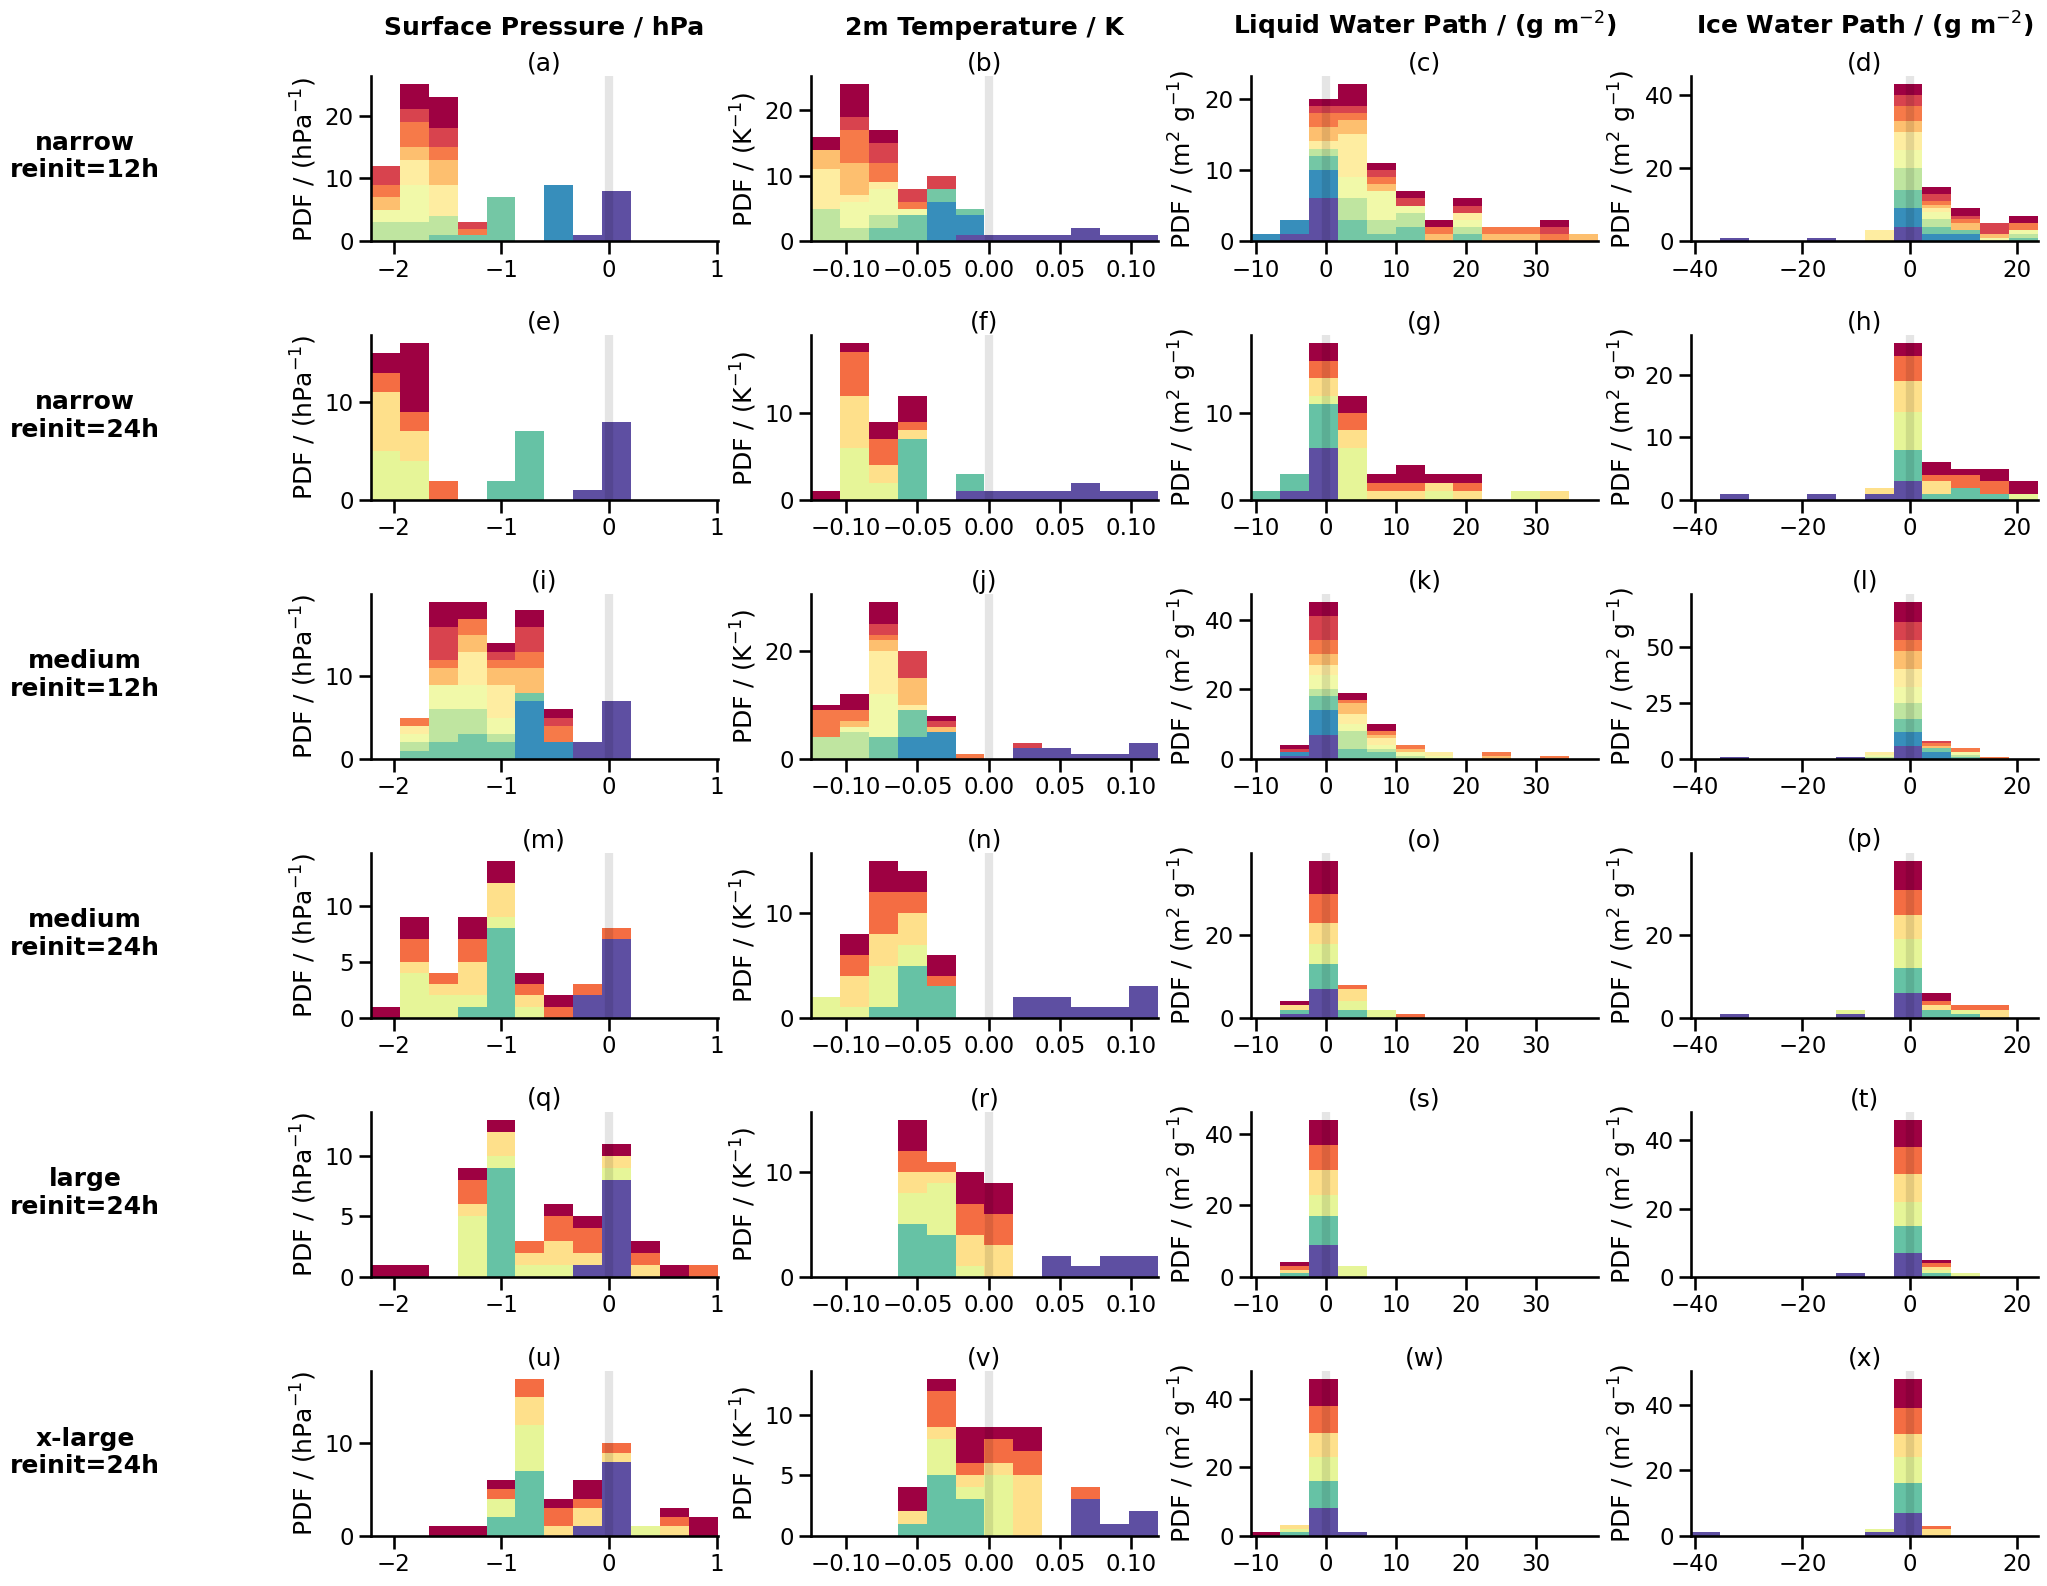

In [12]:
fig, ax = plt.subplots(figsize=(22, 2.7*nexp), ncols = 4, nrows = nexp,)

# List of labels from 'a' to 't'
labels = ['(%s)' % chr(i) for i in range(ord('a'), ord('y') + 1)]

n = 0    
for iexp, expname in enumerate( explist ):
    print(f'... use {expname}')
    dsq = d_std[expname].squeeze()
    d05 = dsq.sel(time = 0.5)
    dref = dsq.sel(time = [0,2]).mean('time')

    
    
    for i, vname in enumerate( varnames ): 
        v = scale[i]*(d05 - dref)[vname]

        plt.sca(ax[iexp,i])
        
        color_cycle = plt.cm.Spectral_r(np.linspace(0, 1, len(d05['segment'])))
#        plt.rcParams['axes.prop_cycle'] = plt.cycler(color=color_cycle)

        vmin, vmax = vlims[vname]
        bins = np.linspace(vmin, vmax, 13)
                
        plt.hist(v.data.T, bins, stacked = True, color=color_cycle)
        ax[iexp,i].axvline(0, color = 'k', lw = 6, alpha = 0.1)
        if iexp == 0:
            ax[iexp,i].set_title( titles[i], fontweight = 'bold', pad = 30)
        ax[iexp,i].set_ylabel(ylabels[i],)
        
        # Add text label in the upper central part of each subplot
        ax[iexp,i].text(0.5, 1.15, labels[n], transform=ax[iexp,i].transAxes, 
            ha='center', va='top', )

        n += 1
        sns.despine()

for iexp, expname in enumerate( explist ):
    for i, vname in enumerate( varnames ): 
        ax[iexp,i].set_xlim( *vlims[vname] )

for i, desc in enumerate( exp_describs ):
    plt.figtext(0.1, 0.88-i*0.16, desc, ha = 'center', fontweight = 'bold' )
plt.tight_layout()
plt.subplots_adjust( left = 0.23 )
plt.savefig(f'../pics/combined_spinup_stats.jpg', dpi = 600)
